Nathaniel Linden-Santangeli 2025

### Prior predictive elicitation for MA Nonessential All

In [1]:
# imports
import jax
import jax.numpy as jnp
import numpy as np
import diffrax as dfrx
import equinox as eqx
import pymc as pm
from pytensor.link.jax.dispatch import jax_funcify
import pytensor.tensor as pt
from pytensor.graph import Apply, Op
import sys, json
import matplotlib.pyplot as plt
import seaborn as sns
import met_brewer as mb

sys.path.append("../")
from utils import *
from pymc_jax_ode import *

sys.path.append("../models/")

# tell jax to use 64bit floats
jax.config.update('jax_platform_name', 'cpu')
jax.config.update("jax_enable_x64", True)

plt.style.use("~/.matplotlib/stylelib/custom.mplstyle")

savedir = '../../../results/param_est/prior_predictive/'

In [2]:
from MA_nonessential_all_diffrax import *

MA_info = json.load(open('../models/MA_nonessential_all.json'))
MA_info_single = json.load(open('../models/MA_single.json'))

# get initial conditions
y0_MA = list(MA_info['init_conds'].values())

# deal with getting AMPKAR idxs
state_names_MA = list(MA_info["init_conds"].keys()) # MA
ampkar_states_MA = MA_info['ampkar_states']
pampkar_states_MA = MA_info['pampkar_states']
ampkar_idxs_MA = [state_names_MA.index(item) for item in ampkar_states_MA]
pampkar_idxs_MA = [state_names_MA.index(item) for item in pampkar_states_MA]

# get metabolism params - same for both models
metab_params = json.load(open('../models/metabolism_params_Coccimiglio.json'))
basal_params = list(metab_params["metab_params_basal"].values())
stress_params = list(metab_params["metab_params_stress"].values())

# cosrtuct ODE rhs objects
MA_rhs = dfrx.ODETerm(MA_nonessential_all(*basal_params))
MA_rhs_stress = dfrx.ODETerm(MA_nonessential_all(*stress_params))

# load data
cyto_data, cyto_std, cyto_times = load_data('../../../Schmitt_et_al_2022_data/fig_2e_cyto.npz')
lyso_data, lyso_std, lyso_times = load_data('../../../Schmitt_et_al_2022_data/fig_2b_lyso.npz')
mito_data, mito_std, mito_times = load_data('../../../Schmitt_et_al_2022_data/fig_2c_mito.npz')

cyto_data = cyto_data.reshape((1, len(cyto_data)))
lyso_data = lyso_data.reshape((1, len(lyso_data)))
mito_data = mito_data.reshape((1, len(mito_data)))
cyto_std = cyto_std.reshape((1, len(cyto_std)))
lyso_std = lyso_std.reshape((1, len(lyso_std)))
mito_std = mito_std.reshape((1, len(mito_std)))

cyto_times_fine = np.linspace(cyto_times.min()*60, cyto_times.max()*60, num=1000)
cyto_data_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_data[0]).reshape((1, len(cyto_times_fine)))
cyto_std_fine= np.interp(cyto_times_fine, cyto_times*60, cyto_std[0]).reshape((1, len(cyto_times_fine)))

# solver params
atol, rtol, evnt_atol, evnt_rtol = 1e-6, 1e-6, 1e-12, 1e-12
pcoeff, icoeff = 0.3, 0.4
dt0=1e-10
tmax_init = 1e3

ca_index = 4
ca_stress = jnp.array([0.25,])

# define simulator funcs
# we will use the cyto times for the models, and thus will just use the cyto data for the likeilihood since that is the hardest to capture, because it is the slowest
@jax.jit
def MA_sim(params):
    sol_stressed, _ = solve_traj_timeDepCaMKK(MA_rhs, MA_rhs_stress, y0_MA, ca_stress, ca_index, params, cyto_times_fine, tmax_init=tmax_init, rtol=rtol, atol=atol, pcoeff=pcoeff, icoeff=icoeff, dcoeff=0.0, dt0=1e-10)

    # compute delta pAMPKAR/AMPKAR_tot
    AMPKAR_stressed = sol_stressed[jnp.array(ampkar_idxs_MA), :].sum(axis=0)
    pAMPKAR_stressed = sol_stressed[jnp.array(pampkar_idxs_MA), :].sum(axis=0)
    result = pAMPKAR_stressed / AMPKAR_stressed
        
    return jnp.reshape(result, (1, len(result)))

# Pytensor Ops
# construct PyTensor Op for simulator
def sol_op_jax_MA(*params):
    return MA_sim(params)
sol_op_jax_jitted_MA = jax.jit(sol_op_jax_MA)

def vjp_sol_op_jax_MA(gz, *params):
        _, vjp_fn = jax.vjp(sol_op_jax_MA, *params)
        return vjp_fn(gz)

jp_sol_op_jax_jitted_MA = eqx.filter_jit(vjp_sol_op_jax_MA)

# using Jax-based sampler, so we do not need the Pytensor ops for the grads
vjp_sol_op_MA = VJPSolOp(jp_sol_op_jax_jitted_MA)
sol_op_MA = SolOp(sol_op_jax_jitted_MA, vjp_sol_op_MA)

@jax_funcify.register(SolOp)
def sol_op_jax_funcify(op, **kwargs):
    return sol_op_jax_MA

@jax_funcify.register(VJPSolOp)
def sol_op_jax_funcify(op, **kwargs):
    return vjp_sol_op_jax_MA

#### Direct prior elicitation using Preliz Maxent

First we elicit priors from the bounds that are specified in the model_info files under the `param_bounds_original` key. These bounds are based on the literature values for the parameters

We choose priors such that 90% of the prior mass is between the bounds

In [3]:
model = 'MA_nonessential_all'

prob_mass = 0.9 # mass between bounds
prior_params = {}

model_info_file = f'../models/{model}.json'
with open(model_info_file, 'r') as file:
        model_info = json.load(file)

bounds = model_info['param_bounds_original']
for param in model_info['params']:
        if len(bounds[param]) > 0:
            result = pz.maxent(pz.LogNormal(), lower=bounds[param][0], 
                                upper=bounds[param][1], mass=prob_mass, plot=False)
            mu = result.params[0]
            sigma = result.params[1]

            # store in a model_info dictionary
            prior_params[param] = {'mu': mu, 'sigma': sigma}
        
        if len(bounds[param]) == 0:
            prior_params[param] = {}

#### PyMC models
Build the PyMC models for the MA and MM models, with lognormal priors on the parameters. 

**Notes:**

- To better attribute variation in the predictions to variation in the params, we will artificially set the variance of the likelihood to be very small. This will allow us to see how the prior predictive density changes as we change the parameters and will eliminate the noise added from sampling from the likelihood.
- We only include locally identifiable params

In [4]:
# orig. pymc models
std_mult = 0.001 # multiplier to reduce likelihood std

def construct_pm_model_MA(
            kOffAMP_mu=prior_params['kOffAMP']['mu'],
            kOffAMP_sigma=prior_params['kOffAMP']['sigma'], 
            kOffADP_mu=prior_params['kOffADP']['mu'], 
            kOffADP_sigma=prior_params['kOffADP']['sigma'], 
            kOffATP_mu=prior_params['kOffATP']['mu'], 
            kOffATP_sigma=prior_params['kOffATP']['sigma'], 
            kOffCaMKK_mu=prior_params['kOffCaMKK']['mu'], 
            kOffCaMKK_sigma=prior_params['kOffCaMKK']['sigma'], 
            kPhosCaMKK_mu=prior_params['kPhosCaMKK']['mu'], 
            kPhosCaMKK_sigma=prior_params['kPhosCaMKK']['sigma'], 
            kOffLKB1_mu=prior_params['kOffLKB1']['mu'], 
            kOffLKB1_sigma=prior_params['kOffLKB1']['sigma'], 
            kPhosLKB1_mu=prior_params['kPhosLKB1']['mu'], 
            kPhosLKB1_sigma=prior_params['kPhosLKB1']['sigma'], 
            kOffPP_mu=prior_params['kOffPP']['mu'], 
            kOffPP_sigma=prior_params['kOffPP']['sigma'], 
            kDephosPP_mu=prior_params['kDephosPP']['mu'], 
            kDephosPP_sigma=prior_params['kDephosPP']['sigma'], 
            kOffAMPK_mu=prior_params['kOffAMPK']['mu'], 
            kOffAMPK_sigma=prior_params['kOffAMPK']['sigma'], 
            kPhosAMPK_mu=prior_params['kPhosAMPK']['mu'], 
            kPhosAMPK_sigma=prior_params['kPhosAMPK']['sigma'], 
            kOffPP1_mu=prior_params['kOffPP1']['mu'], 
            kOffPP1_sigma=prior_params['kOffPP1']['sigma'], 
            kDephosPP1_mu=prior_params['kDephosPP1']['mu'], 
            kDephosPP1_sigma=prior_params['kDephosPP1']['sigma'],
            alphaPP_mu=prior_params['alphaPP']['mu'],
            alphaPP_sigma=prior_params['alphaPP']['sigma'],
            betaLKB1_mu=prior_params['betaLKB1']['mu'],
            betaLKB1_sigma=prior_params['betaLKB1']['sigma'],
            betaCaMKK_mu=prior_params['betaCaMKK']['mu'],
            betaCaMKK_sigma=prior_params['betaCaMKK']['sigma'],
            betaAMP_mu=prior_params['betaAMP']['mu'],
            betaAMP_sigma=prior_params['betaAMP']['sigma'],
            std_mult=0.001
        ):
    # construct pymc model
    with pm.Model() as model:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=kOffCaMKK_mu, sigma=kOffCaMKK_sigma)
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=kPhosCaMKK_mu, sigma=kPhosCaMKK_sigma)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=kOffLKB1_mu, sigma=kOffLKB1_sigma)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=kPhosLKB1_mu, sigma=kPhosLKB1_sigma)
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=kOffPP_mu, sigma=kOffPP_sigma)
        kDephosPP = pm.LogNormal('kDephosPP', mu=kDephosPP_mu, sigma=kDephosPP_sigma)
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=kOffAMPK_mu, sigma=kOffAMPK_sigma)
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=kPhosAMPK_mu, sigma=kPhosAMPK_sigma)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=kOffPP1_mu, sigma=kOffPP1_sigma)
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=kDephosPP1_mu, sigma=kDephosPP1_sigma)
        kOnCaM = pm.Data('kOnCaM', MA_info['nominal_params']['kOnCaM'])
        kOffCaM = pm.Data('kOffCaM', MA_info['nominal_params']['kOffCaM'])
        kPhosCaM = pm.Data('kPhosCaM', MA_info['nominal_params']['kPhosCaM'])
        KmCaM = pm.Data('KmCaM', MA_info['nominal_params']['KmCaM'])
        kDephosCaMKK = pm.Data('kDephosCaMKK', MA_info['nominal_params']['kDephosCaMKK'])
        alphaPP = pm.LogNormal('alphaPP', mu=alphaPP_mu, sigma=alphaPP_sigma)
        betaLKB1 = pm.LogNormal('betaLKB1', mu=betaLKB1_mu, sigma=betaLKB1_sigma)
        betaCaMKK = pm.LogNormal('betaCaMKK', mu=betaCaMKK_mu, sigma=betaCaMKK_sigma)
        betaAMP = pm.LogNormal('betaAMP', mu=betaAMP_mu, sigma=betaAMP_sigma)
        
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK,
                    kPhosCaMKK, kOnLKB1, kOffLKB1, kPhosLKB1, kOnPP, kOffPP, kDephosPP, kOnAMPK, kOffAMPK, kPhosAMPK, kOnPP1, kOffPP1, kDephosPP1, 
                    kOnCaM, kOffCaM, kPhosCaM, KmCaM, kDephosCaMKK,
                    alphaPP, betaLKB1, betaCaMKK, betaAMP]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MA(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model

MA_pm_model_default = construct_pm_model_MA(std_mult=0.001)

Define functions to plot prior predictive densities and statistics thereof

In [5]:
def plot_func_trajectories(predictions, ax):
    # print(predictions.shape)
    for i in range(predictions.shape[0]):
        # print(predictions)
        ax.plot(cyto_times_fine/60, jnp.squeeze(predictions[i,:,:]), 'b', alpha=0.1, linewidth=0.75)

    ax.plot([0,1], [np.nan, np.nan], 'b', label='prior predictive samples')
    ax.plot(cyto_times, jnp.squeeze(cyto_data), 'k--', label='AMPKAR cytoplasm')
    # ax.plot(lyso_times, jnp.squeeze(lyso_data), 'k:', label='AMPKAR lysosome')
    # ax.plot(mito_times, jnp.squeeze(mito_data), 'k-.', label='AMPKAR mitochondria')
    ax.set_xlabel('time (min)', fontsize=10.0)
    ax.legend(bbox_to_anchor=(3., 1), loc='upper right', fontsize=8.0, ncols=2)
    ax.set_ylabel(r'$pAMPKAR(t)/AMPKAR_{tot}$', fontsize=10.0)
    ax.set_xticks([0, 10, 20])
    ax.set_yticks([0, 0.5, 1.0])
    ax.set_xticklabels(['0', '10', '20'], fontsize=8.0)
    ax.set_yticklabels(['0.0','0.5', '1.0'], fontsize=8.0)
    ax.set_xlim([0, np.max(cyto_times_fine)/60])
    ax.set_ylim([0, 1.05])

# calculate time to half max of pAMPKAR_stressed/AMPKAR_stressed
def compute_half_max(arr):
    half_max = arr.max() / 2
    half_max_idx = jnp.argmin(jnp.abs(arr - half_max))
    return half_max_idx

# compute t_half_max for data
t_half_cyto = cyto_times[compute_half_max(cyto_data)]
t_half_lyso = lyso_times[compute_half_max(lyso_data)]
t_half_mito = mito_times[compute_half_max(mito_data)]

print(f'The cyto time to half-max is {t_half_cyto:.2f} mins (Normalized: {t_half_cyto/cyto_times[-1]:.2f})')
print(f'The lyso time to half-max is {t_half_lyso:.2f} mins (Normalized: {t_half_lyso/lyso_times[-1]:.2f})')
print(f'The mito time to half-max is {t_half_mito:.2f} mins (Normalized: {t_half_mito/mito_times[-1]:.2f})')

def plot_func_densities(predictions, fig=None, ax=None, linestyle='-', plot_data=True, color='k'):

    if ax is None:
        fig, ax = plt.subplots(1,3, figsize=(8,4))
    # compute t_halfs
    t_halfs_idxs = jnp.apply_along_axis(compute_half_max, 1, predictions[:,0,:])

    # get times normalized to t_max
    t_halfs = [cyto_times_fine[i]/60 for i in t_halfs_idxs]

    # density of IC
    sns.kdeplot(predictions[:,0,0], color=color, ax=ax[0], label=r'Initial $pAMPKAR(0)/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[0].set_ylabel('density', fontsize=10.0)
    ax[0].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[0].set_xlim([0,1])
    ax[0].set_title(r'$\frac{pAMPKAR(t=0)}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[0].set_xticks([0, 0.5, 1.0])
    ax[0].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of final
    sns.kdeplot(predictions[:,0,-1], color=color, ax=ax[1], label=r'Final $pAMPKAR(t=t_{end})/AMPKAR_{tot}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[1].set_xlabel(r'fraction act. sensor', fontsize=10.0)
    ax[1].set_title(r'$\frac{pAMPKAR(t=t_{end})}{AMPKAR_{tot}}$', fontsize=11.0)
    ax[1].set_ylabel('density', fontsize=10.0)
    ax[1].set_xlim([0,1])
    ax[1].set_xticks([0, 0.5, 1.0])
    ax[1].set_xticklabels(['0.0','0.5', '1.0'], fontsize=8.0)

    # density of t_half
    sns.kdeplot(t_halfs, color=color, ax=ax[2], label=r'$t_{1/2 \ max}$', 
                fill=True, linewidth=1.5, alpha=0.25, linestyle=linestyle)
    ax[2].set_xlabel(r'time (min)', fontsize=10.0)
    ax[2].set_title(r'$t_{1/2 \ max}$', fontsize=11.0)

    if plot_data:
        ylim = ax[2].get_ylim()
        ax[2].vlines(t_half_lyso, ylim[0], ylim[1], linestyles=':', colors='k')
        ax[2].vlines(t_half_mito, ylim[0], ylim[1], linestyles=(0, (3, 1, 1, 1)), colors='k')
        ax[2].vlines(t_half_cyto, ylim[0], ylim[1], linestyles='--', colors='k')
        # ax[2].text(1.05*t_half_cyto, 0.4*ylim[1], 'cytoplasm', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_lyso, 0.4*ylim[1], 'lysosome', rotation=90, verticalalignment='bottom')
        # ax[2].text(1.05*t_half_mito, 0.4*ylim[1], 'mitochondria', rotation=90, verticalalignment='bottom')
        ax[2].set_ylim(ylim) 
    ax[2].set_ylabel('density', fontsize=10.0)
    
    if fig is None:
        return fig, ax

The cyto time to half-max is 9.36 mins (Normalized: 0.35)
The lyso time to half-max is 2.89 mins (Normalized: 0.11)
The mito time to half-max is 5.32 mins (Normalized: 0.21)


## Predictive elicitation 

In [6]:
with MA_pm_model_default:
    prior_pred_MA_default = pm.sample_prior_predictive(samples=50)

Sampling: [alphaPP, betaAMP, betaCaMKK, betaLKB1, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


/var/folders/8n/spw3_jx50513cdpgqqxx58cr0000gp/T/ipykernel_87610/1268344807.py:8: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


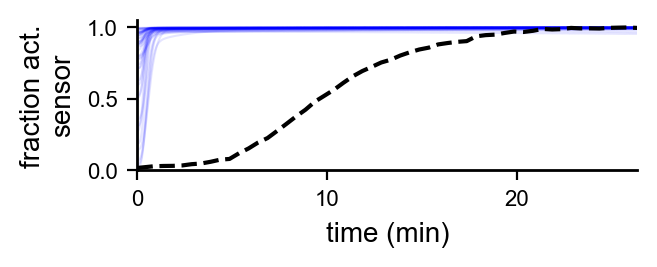

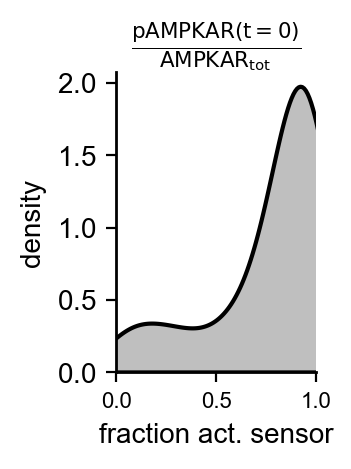

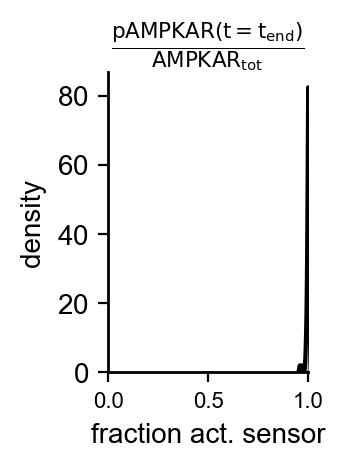

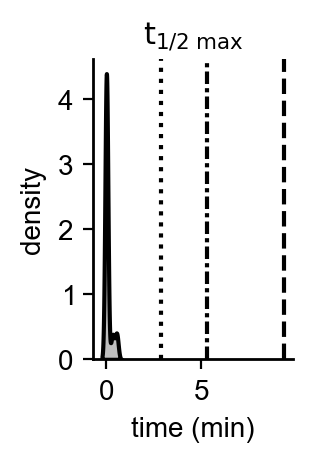

In [7]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MA_nonessential_all_default_legend.pdf')
leg.remove()
fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential_all_default.pdf', bbox_inches='tight', transparent=True)
# ax.set_title('MA Single Model - Original Prior predictive')

fig_orig_ma_ratio_basal, ax_orig_ma_ratio_basal = get_sized_fig_ax(1.0, 1.5)
fig_orig_ma_ratio, ax_orig_ma_ratio = get_sized_fig_ax(1.0, 1.5)
fig_orig_ma_t_half_max, ax_orig_ma_t_half_max = get_sized_fig_ax(1.0, 1.5)

axs = [ax_orig_ma_ratio_basal, ax_orig_ma_ratio, ax_orig_ma_t_half_max]
figs= [fig_orig_ma_ratio_basal, fig_orig_ma_ratio, fig_orig_ma_t_half_max]

plot_func_densities(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs)

This is not great, so lets use the priors from the MA single model

In [8]:
MA_pm_model_updated = construct_pm_model_MA(
            kOffAMP_mu=MA_info_single['prior_params']['kOffAMP']['mu'],
            kOffAMP_sigma=MA_info_single['prior_params']['kOffAMP']['sigma'], 
            kOffADP_mu=MA_info_single['prior_params']['kOffADP']['mu'], 
            kOffADP_sigma=MA_info_single['prior_params']['kOffADP']['sigma'], 
            kOffATP_mu=MA_info_single['prior_params']['kOffATP']['mu'], 
            kOffATP_sigma=MA_info_single['prior_params']['kOffATP']['sigma'], 
            kOffCaMKK_mu=MA_info_single['prior_params']['kOffCaMKK']['mu'], 
            kOffCaMKK_sigma=MA_info_single['prior_params']['kOffCaMKK']['sigma'], 
            kPhosCaMKK_mu=MA_info_single['prior_params']['kPhosCaMKK']['mu'], 
            kPhosCaMKK_sigma=MA_info_single['prior_params']['kPhosCaMKK']['sigma'], 
            kOffLKB1_mu=MA_info_single['prior_params']['kOffLKB1']['mu'], 
            kOffLKB1_sigma=MA_info_single['prior_params']['kOffLKB1']['sigma'], 
            kPhosLKB1_mu=MA_info_single['prior_params']['kPhosLKB1']['mu'], 
            kPhosLKB1_sigma=MA_info_single['prior_params']['kPhosLKB1']['sigma'], 
            kOffPP_mu=MA_info_single['prior_params']['kOffPP']['mu'], 
            kOffPP_sigma=MA_info_single['prior_params']['kOffPP']['sigma'], 
            kDephosPP_mu=prior_params['kDephosPP']['mu'], 
            kDephosPP_sigma=MA_info_single['prior_params']['kDephosPP']['sigma'], 
            kOffAMPK_mu=MA_info_single['prior_params']['kOffAMPK']['mu'], 
            kOffAMPK_sigma=MA_info_single['prior_params']['kOffAMPK']['sigma'], 
            kPhosAMPK_mu=MA_info_single['prior_params']['kPhosAMPK']['mu'], 
            kPhosAMPK_sigma=MA_info_single['prior_params']['kPhosAMPK']['sigma'], 
            kOffPP1_mu=MA_info_single['prior_params']['kOffPP1']['mu'], 
            kOffPP1_sigma=MA_info_single['prior_params']['kOffPP1']['sigma'], 
            kDephosPP1_mu=MA_info_single['prior_params']['kDephosPP1']['mu'], 
            kDephosPP1_sigma=MA_info_single['prior_params']['kDephosPP1']['sigma'],
            std_mult=0.001
        )

with MA_pm_model_updated:
    prior_pred_MA_updated = pm.sample_prior_predictive(samples=50)

Sampling: [alphaPP, betaAMP, betaCaMKK, betaLKB1, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


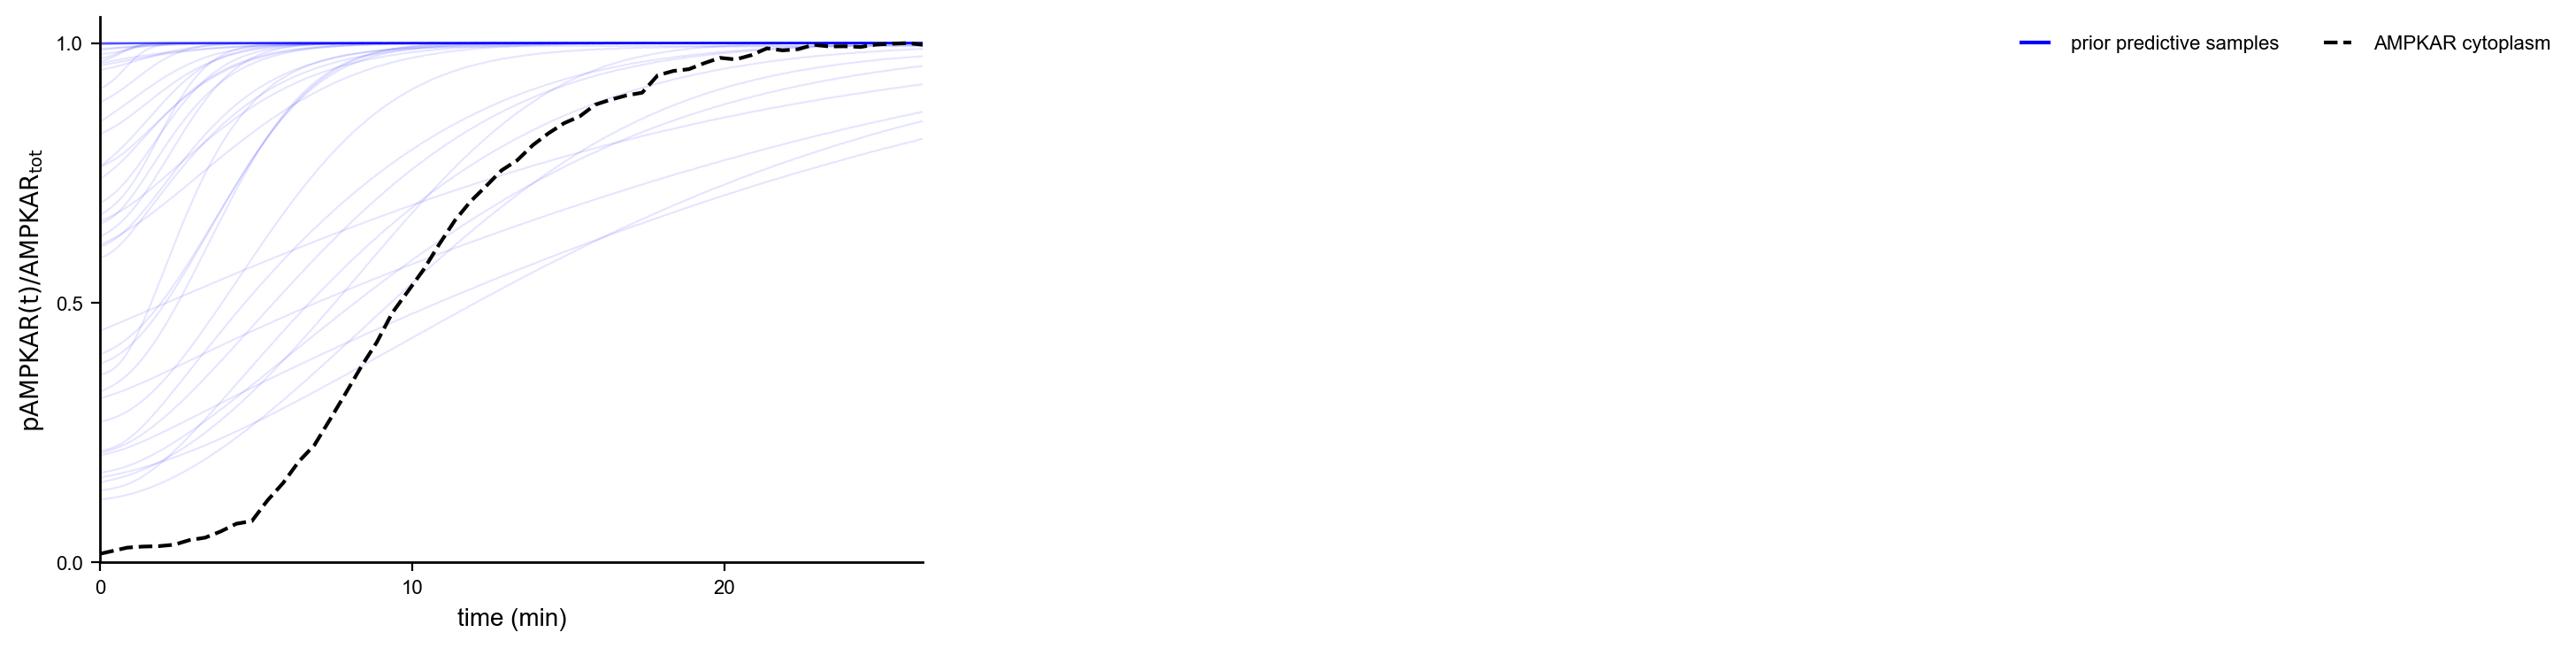

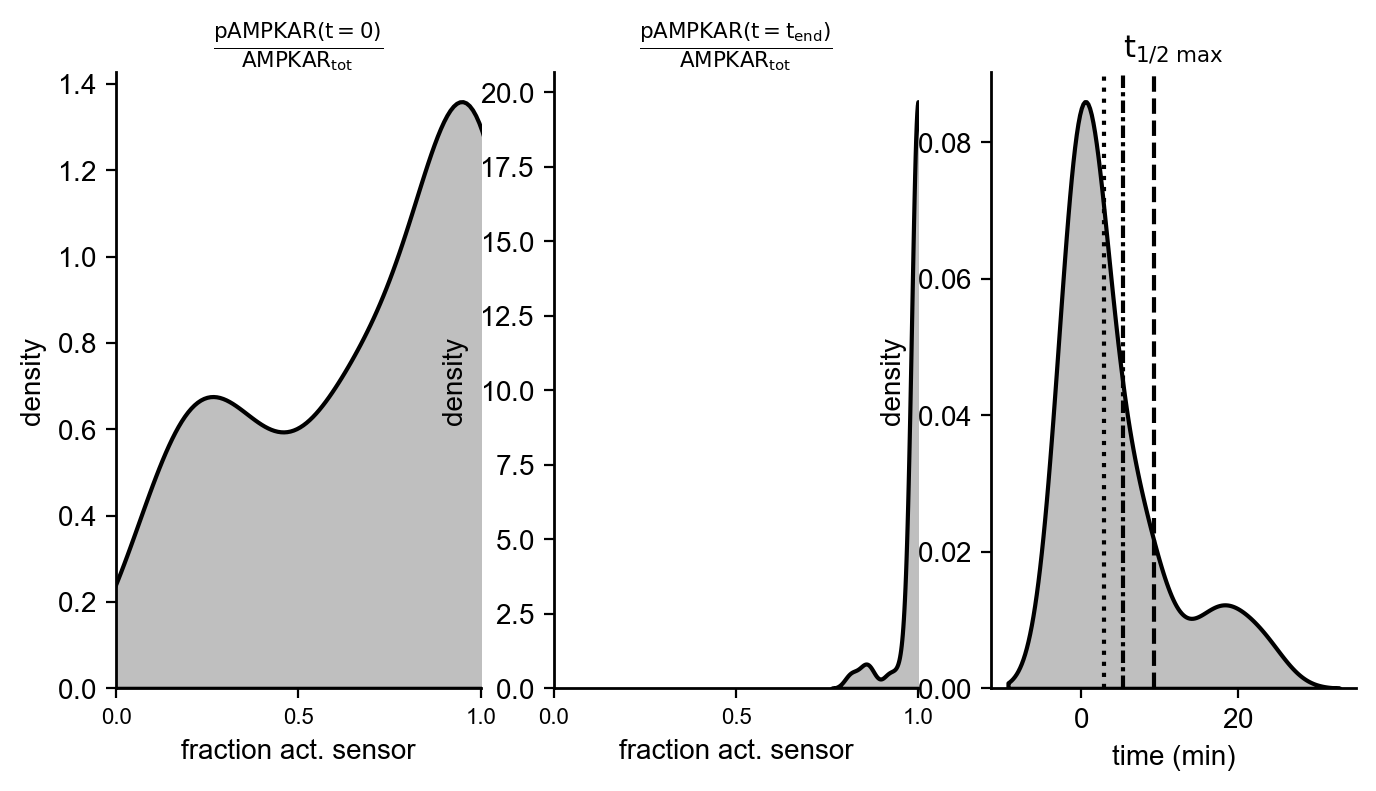

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
plot_func_trajectories(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:], ax)

plot_func_densities(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:])

Better, but there are still lots of samples with very high initial activation, lets refine

In [10]:
def construct_pm_model_MA_updated(
            kOffAMP_mu=-5.5,
            kOffAMP_sigma=1.0, 
            kOffADP_mu=-5.5, 
            kOffADP_sigma=1.0, 
            kOffATP_mu=-5.5, 
            kOffATP_sigma=1.0, 
            kOffCaMKK_mu=-2.75, 
            kOffCaMKK_sigma=1.0, 
            kPhosCaMKK_mu=-3.5, 
            kPhosCaMKK_sigma=1.0, 
            kOffLKB1_mu=0.0, 
            kOffLKB1_sigma=1.0, 
            kPhosLKB1_mu=-3.5, 
            kPhosLKB1_sigma=1.0, 
            kOffPP_mu=-1.0, 
            kOffPP_sigma=1.0,
            kDephosPP_mu=-3, 
            kDephosPP_sigma=1.0, 
            kOffAMPK_mu=1.0, 
            kOffAMPK_sigma=1.0, 
            kPhosAMPK_mu=-3.0, 
            kPhosAMPK_sigma=1.0, 
            kOffPP1_mu=0.0, 
            kOffPP1_sigma=1.0, 
            kDephosPP1_mu=-1.5, 
            kDephosPP1_sigma=1.0,
            alphaPP_mu=-1.6,
            alphaPP_sigma=1.0,
            betaLKB1_mu=3.2,
            betaLKB1_sigma=0.9275,
            betaCaMKK_mu=3.2,
            betaCaMKK_sigma=0.9275,
            betaAMP_mu=3.2,
            betaAMP_sigma=0.9275,
            std_mult=0.001
        ):
   # construct pymc model
    with pm.Model() as model:
        # define priors
        params = []
        kOnAMP = pm.Data('kOnAMP', 1.0)
        kOffAMP = pm.LogNormal('kOffAMP', mu=kOffAMP_mu, sigma=kOffAMP_sigma)
        kOnADP = pm.Data('kOnADP', 1.0)
        kOffADP = pm.LogNormal('kOffADP', mu=kOffADP_mu, sigma=kOffADP_sigma)
        kOnATP = pm.Data('kOnATP', 1.0)
        kOffATP = pm.LogNormal('kOffATP', mu=kOffATP_mu, sigma=kOffATP_sigma)
        kOnCaMKK = pm.Data('kOnCaMKK', 1.0)
        kOffCaMKK = pm.LogNormal('kOffCaMKK', mu=kOffCaMKK_mu, sigma=kOffCaMKK_sigma)
        kPhosCaMKK = pm.LogNormal('kPhosCaMKK', mu=kPhosCaMKK_mu, sigma=kPhosCaMKK_sigma)
        kOnLKB1 = pm.Data('kOnLKB1', 1.0)
        kOffLKB1 = pm.LogNormal('kOffLKB1', mu=kOffLKB1_mu, sigma=kOffLKB1_sigma)
        kPhosLKB1 = pm.LogNormal('kPhosLKB1', mu=kPhosLKB1_mu, sigma=kPhosLKB1_sigma)
        kOnPP = pm.Data('kOnPP', 1.0)
        kOffPP = pm.LogNormal('kOffPP', mu=kOffPP_mu, sigma=kOffPP_sigma)
        kDephosPP = pm.LogNormal('kDephosPP', mu=kDephosPP_mu, sigma=kDephosPP_sigma)
        kOnAMPK = pm.Data('kOnAMPK', 1.0)
        kOffAMPK = pm.LogNormal('kOffAMPK', mu=kOffAMPK_mu, sigma=kOffAMPK_sigma)
        kPhosAMPK = pm.LogNormal('kPhosAMPK', mu=kPhosAMPK_mu, sigma=kPhosAMPK_sigma)
        kOnPP1 = pm.Data('kOnPP1', 1.0)
        kOffPP1 = pm.LogNormal('kOffPP1', mu=kOffPP1_mu, sigma=kOffPP1_sigma)
        kDephosPP1 = pm.LogNormal('kDephosPP1', mu=kDephosPP1_mu, sigma=kDephosPP1_sigma)
        kOnCaM = pm.Data('kOnCaM', MA_info['nominal_params']['kOnCaM'])
        kOffCaM = pm.Data('kOffCaM', MA_info['nominal_params']['kOffCaM'])
        kPhosCaM = pm.Data('kPhosCaM', MA_info['nominal_params']['kPhosCaM'])
        KmCaM = pm.Data('KmCaM', MA_info['nominal_params']['KmCaM'])
        kDephosCaMKK = pm.Data('kDephosCaMKK', MA_info['nominal_params']['kDephosCaMKK'])
        alphaPP = pm.LogNormal('alphaPP', mu=alphaPP_mu, sigma=alphaPP_sigma)
        betaLKB1 = pm.LogNormal('betaLKB1', mu=betaLKB1_mu, sigma=betaLKB1_sigma)
        betaCaMKK = pm.LogNormal('betaCaMKK', mu=betaCaMKK_mu, sigma=betaCaMKK_sigma)
        betaAMP = pm.LogNormal('betaAMP', mu=betaAMP_mu, sigma=betaAMP_sigma)
        
        params = [kOnAMP, kOffAMP, kOnADP, kOffADP, kOnATP, kOffATP, kOnCaMKK, kOffCaMKK,
                    kPhosCaMKK, kOnLKB1, kOffLKB1, kPhosLKB1, kOnPP, kOffPP, kDephosPP, kOnAMPK, kOffAMPK, kPhosAMPK, kOnPP1, kOffPP1, kDephosPP1, 
                    kOnCaM, kOffCaM, kPhosCaM, KmCaM, kDephosCaMKK,
                    alphaPP, betaLKB1, betaCaMKK, betaAMP]

        # define simulator
        sim = pm.Deterministic('simulation', sol_op_MA(*params))

        # define likelihood
        pm.Normal('like', mu=sim, sigma=cyto_std_fine*std_mult, observed=cyto_data_fine)

    return model

pz.predictive_explorer(construct_pm_model_MA_updated, plot_func=plot_func_trajectories, samples=50)

In [11]:
updated_prior_params_MA = {
    'kOffAMP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffADP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffATP':    {'mu': -5.5,  'sigma': 1.0},
    'kOffCaMKK':  {'mu': -2.75, 'sigma': 1.0},
    'kPhosCaMKK': {'mu': -3.5,  'sigma': 1.0},
    'kOffLKB1':   {'mu': 0.0,   'sigma': 1.0},
    'kPhosLKB1':  {'mu': -3.5,  'sigma': 1.0},
    'kOffPP':     {'mu': -1.0,  'sigma': 1.0},
    'kDephosPP':  {'mu': -2,    'sigma': 1.0},
    'kOffAMPK':   {'mu': 0.5,   'sigma': 1.0},
    'kPhosAMPK':  {'mu': -2.0,  'sigma': 1.0},
    'kOffPP1':    {'mu': 1.0,   'sigma': 1.0},
    'kDephosPP1': {'mu': -1.5,  'sigma': 1.0},
    'alphaPP':    {'mu': -1.6,  'sigma': 1.0},
    'betaLKB1':   {'mu': 3.2,   'sigma': 0.9275},
    'betaCaMKK':  {'mu': 3.2,   'sigma': 0.9275},
    'betaAMP':    {'mu': 3.2,   'sigma': 0.9275},
    }

Run more samples to get a better sense of the complete prior predictive density.

In [12]:
MA_pm_model_updated = construct_pm_model_MA_updated(
    kOffAMP_mu=updated_prior_params_MA['kOffAMP']['mu'],
    kOffAMP_sigma=updated_prior_params_MA['kOffAMP']['sigma'],
    kOffADP_mu=updated_prior_params_MA['kOffADP']['mu'],
    kOffADP_sigma=updated_prior_params_MA['kOffADP']['sigma'],
    kOffATP_mu=updated_prior_params_MA['kOffATP']['mu'],
    kOffATP_sigma=updated_prior_params_MA['kOffATP']['sigma'],
    kOffCaMKK_mu=updated_prior_params_MA['kOffCaMKK']['mu'],
    kOffCaMKK_sigma=updated_prior_params_MA['kOffCaMKK']['sigma'],
    kPhosCaMKK_mu=updated_prior_params_MA['kPhosCaMKK']['mu'],
    kPhosCaMKK_sigma=updated_prior_params_MA['kPhosCaMKK']['sigma'],
    kOffLKB1_mu=updated_prior_params_MA['kOffLKB1']['mu'],
    kOffLKB1_sigma=updated_prior_params_MA['kOffLKB1']['sigma'],
    kPhosLKB1_mu=updated_prior_params_MA['kPhosLKB1']['mu'],
    kPhosLKB1_sigma=updated_prior_params_MA['kPhosLKB1']['sigma'],
    kOffPP_mu=updated_prior_params_MA['kOffPP']['mu'],
    kOffPP_sigma=updated_prior_params_MA['kOffPP']['sigma'],
    kDephosPP_mu=updated_prior_params_MA['kDephosPP']['mu'],
    kDephosPP_sigma=updated_prior_params_MA['kDephosPP']['sigma'],
    kOffAMPK_mu=updated_prior_params_MA['kOffAMPK']['mu'],
    kOffAMPK_sigma=updated_prior_params_MA['kOffAMPK']['sigma'],
    kPhosAMPK_mu=updated_prior_params_MA['kPhosAMPK']['mu'],
    kPhosAMPK_sigma=updated_prior_params_MA['kPhosAMPK']['sigma'],
    kOffPP1_mu=updated_prior_params_MA['kOffPP1']['mu'],
    kOffPP1_sigma=updated_prior_params_MA['kOffPP1']['sigma'],
    kDephosPP1_mu=updated_prior_params_MA['kDephosPP1']['mu'],
    kDephosPP1_sigma=updated_prior_params_MA['kDephosPP1']['sigma'],
    alphaPP_mu=updated_prior_params_MA['alphaPP']['mu'],
    alphaPP_sigma=updated_prior_params_MA['alphaPP']['sigma'],
    betaLKB1_mu=updated_prior_params_MA['betaLKB1']['mu'],
    betaLKB1_sigma=updated_prior_params_MA['betaLKB1']['sigma'],
    betaCaMKK_mu=updated_prior_params_MA['betaCaMKK']['mu'],
    betaCaMKK_sigma=updated_prior_params_MA['betaCaMKK']['sigma'],
    betaAMP_mu=updated_prior_params_MA['betaAMP']['mu'],
    betaAMP_sigma=updated_prior_params_MA['betaAMP']['sigma'],
)

with MA_pm_model_updated:
    prior_pred_MA_updated = pm.sample_prior_predictive(samples=500)

Sampling: [alphaPP, betaAMP, betaCaMKK, betaLKB1, kDephosPP, kDephosPP1, kOffADP, kOffAMP, kOffAMPK, kOffATP, kOffCaMKK, kOffLKB1, kOffPP, kOffPP1, kPhosAMPK, kPhosCaMKK, kPhosLKB1, like]


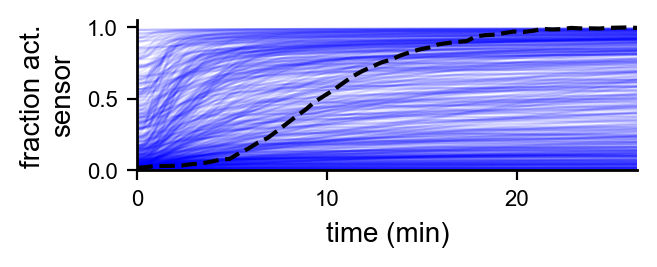

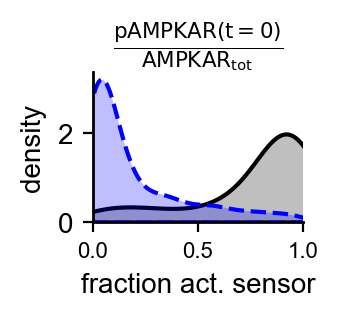

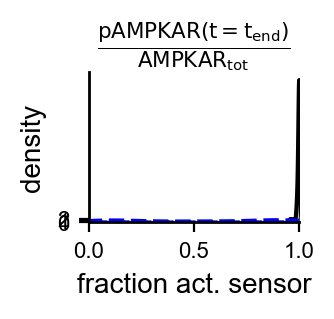

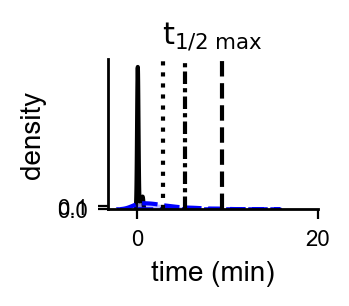

In [13]:
fig, ax = get_sized_fig_ax(2.5, 0.75)
plot_func_trajectories(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:], ax)
ax.set_ylabel('fraction act.\nsensor') # + r'$\frac{pAMPKAR(t)}{AMPKAR_{tot}}$')

leg = ax.get_legend()
export_legend(leg, savedir + 'prior_pred_MA_nonessential_all_updated_legend.pdf')
leg.remove()
# fig.tight_layout()
fig.savefig(savedir + 'prior_pred_MA_nonessential_all_updated.pdf', bbox_inches='tight', transparent=True)

# fig, ax = plot_func_densities(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:])

fig_orig_ma_ratio_basal, ax_orig_ma_ratio_basal = get_sized_fig_ax(1.05, 0.75)
fig_orig_ma_ratio, ax_orig_ma_ratio = get_sized_fig_ax(1.05, 0.75)
fig_orig_ma_t_half_max, ax_orig_ma_t_half_max = get_sized_fig_ax(1.05, 0.75)

axs = [ax_orig_ma_ratio_basal, ax_orig_ma_ratio, ax_orig_ma_t_half_max]
figs= [fig_orig_ma_ratio_basal, fig_orig_ma_ratio, fig_orig_ma_t_half_max]

plot_func_densities(prior_pred_MA_default.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, plot_data=False)
plot_func_densities(prior_pred_MA_updated.prior_predictive['like'].values[0,:,:,:], fig=figs, ax=axs, linestyle='--', color='b')

# axs[0].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
# axs[1].legend(['orginal', 'updated'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)
axs[2].legend(['orginal priors', 'refined priors', 'lysosome' , 'mitochondria', 'cytoplasm'], loc='upper right', bbox_to_anchor=(3, 1.0), fontsize=8.0)

leg = axs[2].get_legend()
export_legend(leg, savedir + 'prior_pred_stats_MA_nonessential_all_updated_legend.pdf')
leg.remove()

# axs[0].set_ylim([0, 20])
# axs[0].set_yticks([0, 10, 20])
# axs[0].set_yticklabels(['0', '10', '20'], fontsize=8.0)

axs[1].set_yticks([0, 1, 2])
axs[1].set_yticklabels(['0', '1', '2'], fontsize=8.0)

axs[2].set_yticks([0, 0.1])
axs[2].set_yticklabels(['0.0', '0.1'], fontsize=8.0)
axs[2].set_xticks([0,20])
axs[2].set_xticklabels(['0', '20'], fontsize=8.0)

figs[0].savefig(savedir + 'prior_pred_MA_nonessential_all_updated_ratio_basal.pdf', bbox_inches='tight', transparent=True)
figs[1].savefig(savedir + 'prior_pred_MA_nonessential_all_updated_ratio.pdf', bbox_inches='tight', transparent=True)
figs[2].savefig(savedir + 'prior_pred_MA_nonessential_all_updated_t_half_max.pdf', bbox_inches='tight', transparent=True)

# axs[2].set_yscale('log')
# axs[2].set_xscale('log')

In [14]:
#  95% hdi of updated prior for bounds for GSA
MA_bounds_updated = {}
MA_prior_params_updated = {}
for param in MA_info['params']:
    if param in updated_prior_params_MA.keys():
        # hdi
        bounds = list(pz.LogNormal(mu=updated_prior_params_MA[param]['mu'], sigma=updated_prior_params_MA[param]['sigma']).hdi(0.95, fmt='.8f'))
        MA_bounds_updated[param] = bounds

        # prior params
        MA_prior_params_updated[param] = updated_prior_params_MA[param]
    else:
        MA_bounds_updated[param] = []
        MA_prior_params_updated[param] = {}

# update the model info file with the new bounds
MA_info['param_bounds'] =  MA_bounds_updated
MA_info['prior_params'] = MA_prior_params_updated

# save the updated model info
with open('../models/MA_nonessential_all.json', 'w') as file:
    json.dump(MA_info, file, indent=4)